In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Option 1: Using California housing dataset (recommended alternative)
from sklearn.datasets import fetch_california_housing
X, _ = fetch_california_housing(return_X_y=True)

# Option 2: Using Ames housing dataset (another recommended alternative)
# from sklearn.datasets import fetch_openml
# housing = fetch_openml(name="house_prices", as_frame=True)

# If you absolutely need the original Boston dataset for educational purposes about ethical issues:
# import pandas as pd
# import numpy as np
# 
# data_url = "http://lib.stat.cmu.edu/datasets/boston"
# raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
# data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
# target = raw_df.values[1::2, 2]

In [12]:
X = pd.DataFrame(X)

In [13]:
X

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


<Axes: xlabel='0', ylabel='4'>

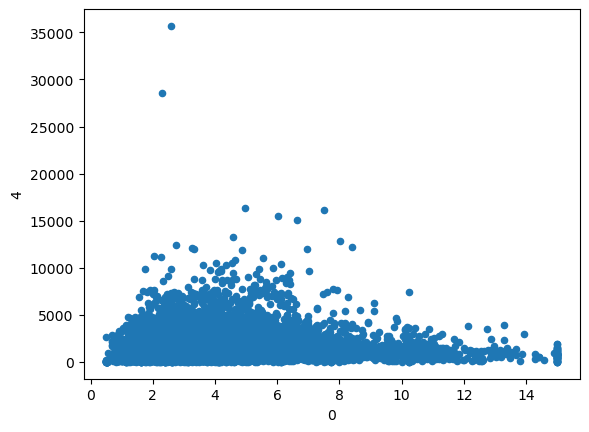

In [29]:
X.plot(kind='scatter', x=0, y=4)

In [25]:
X.describe()

,0,1,2,3,4,5,6,7
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [47]:
mu = X.mean()
sigma = X.std()
Xnorm = (X - mu) / sigma

Xnorm

,0,1,2,3,4,5,6,7
0,2.344709,0.982119,0.628544,-0.153754,-0.974405,-0.049595,1.052523,-1.327803
1,2.332181,-0.607004,0.327033,-0.263329,0.861418,-0.092510,1.043159,-1.322812
2,1.782656,1.856137,1.155592,-0.049015,-0.820757,-0.025842,1.038478,-1.332794
3,0.932945,1.856137,0.156962,-0.049832,-0.766010,-0.050328,1.038478,-1.337785
4,-0.012881,1.856137,0.344702,-0.032905,-0.759828,-0.085614,1.038478,-1.337785
...,...,...,...,...,...,...,...,...
20635,-1.216099,-0.289180,-0.155020,0.077352,-0.512579,-0.049109,1.801603,-0.758808
20636,-0.691576,-0.845373,0.276874,0.462353,-0.944382,0.005021,1.806285,-0.818702
20637,-1.142566,-0.924829,-0.090316,0.049413,-0.369528,-0.071733,1.778194,-0.823693
20638,-1.054557,-0.845373,-0.040210,0.158774,-0.604415,-0.091223,1.778194,-0.873605


<Axes: xlabel='0', ylabel='4'>

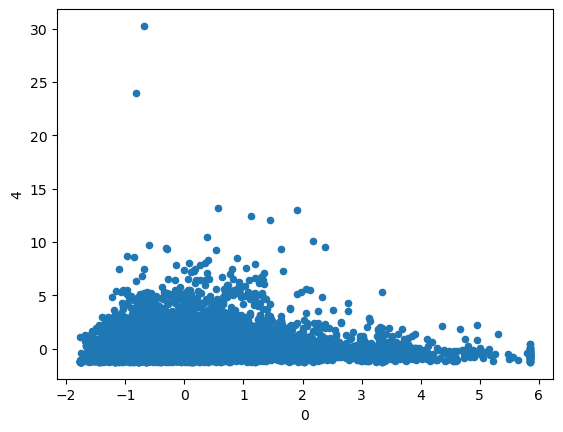

In [30]:
Xnorm.plot(kind='scatter', x=0, y=4)

In [31]:
from scipy.linalg import svd

In [48]:
U, s, Vt = svd(Xnorm, full_matrices = False)

In [49]:
Sigma = np.diag(s)
V = Vt.T

In [50]:
U @ Sigma @ V.T

array([[ 2.34470896,  0.98211887,  0.62854423, ..., -0.04959533,
         1.05252278, -1.32780305],
       [ 2.33218146, -0.60700421,  0.32703343, ..., -0.09250999,
         1.04315928, -1.32281187],
       [ 1.78265622,  1.85613656,  1.15559247, ..., -0.0258419 ,
         1.03847753, -1.33279424],
       ...,
       [-1.14256563, -0.92482882, -0.09031584, ..., -0.07173277,
         1.77819439, -0.82369324],
       [-1.05455737, -0.84537267, -0.04021014, ..., -0.09122294,
         1.77819439, -0.87360511],
       [-0.78011057, -1.00428498, -0.07044081, ..., -0.0436811 ,
         1.75010387, -0.83367562]])

In [51]:
Xnorm

,0,1,2,3,4,5,6,7
0,2.344709,0.982119,0.628544,-0.153754,-0.974405,-0.049595,1.052523,-1.327803
1,2.332181,-0.607004,0.327033,-0.263329,0.861418,-0.092510,1.043159,-1.322812
2,1.782656,1.856137,1.155592,-0.049015,-0.820757,-0.025842,1.038478,-1.332794
3,0.932945,1.856137,0.156962,-0.049832,-0.766010,-0.050328,1.038478,-1.337785
4,-0.012881,1.856137,0.344702,-0.032905,-0.759828,-0.085614,1.038478,-1.337785
...,...,...,...,...,...,...,...,...
20635,-1.216099,-0.289180,-0.155020,0.077352,-0.512579,-0.049109,1.801603,-0.758808
20636,-0.691576,-0.845373,0.276874,0.462353,-0.944382,0.005021,1.806285,-0.818702
20637,-1.142566,-0.924829,-0.090316,0.049413,-0.369528,-0.071733,1.778194,-0.823693
20638,-1.054557,-0.845373,-0.040210,0.158774,-0.604415,-0.091223,1.778194,-0.873605


In [52]:
np.allclose(Xnorm, U @ Sigma @ V.T)

True

In [53]:
mu + sigma * pd.DataFrame(U @ Sigma @ V.T)

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [54]:
np.allclose(X, mu + sigma * pd.DataFrame(U @ Sigma @ V.T))

True